# My video trajectory visualization

Bu notebook `my_video_test.pkl` için Trajectron++ görselleştirme akışını içerir. Gerekli yerleri (model yolu, checkpoint, pkl adı) güncelleyebilirsiniz.


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.home() / "Trajectron-plus-plus"
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "trajectron"))

print("Paths OK")


Paths OK


In [2]:
import dill
import json
import torch
import numpy as np
import matplotlib.pyplot as plt

from environment import Environment
from visualization.visualization import visualize_distribution
from utils import prediction_output_to_trajectories
from model.model_registrar import ModelRegistrar
from model.online.online_trajectron import OnlineTrajectron


In [3]:
PROCESSED_DIR = PROJECT_ROOT / "experiments" / "processed"

with open(PROCESSED_DIR / "my_video_test.pkl", "rb") as f:
    eval_env = dill.load(f)

print("Loaded environment")
print("Scenes:", len(eval_env.scenes))


Loaded environment
Scenes: 1


In [4]:
MODEL_DIR = PROJECT_ROOT / "experiments" / "pedestrians" / "models" / \
            "models_26_Dec_2025_14_50_24_eth_demo"
CHECKPOINT = 3  # kendi checkpoint'in

with open(MODEL_DIR / "config.json", "r") as f:
    hyperparams = json.load(f)

hyperparams["incl_robot_node"] = False
hyperparams["offline_scene_graph"] = True

model_registrar = ModelRegistrar(MODEL_DIR, device="cpu")
model_registrar.load_models(iter_num=CHECKPOINT)

online_traj = OnlineTrajectron(
    model_registrar,
    hyperparams,
    device="cpu"
)

print("OnlineTrajectron ready")



Loading from /Users/simayyalcin/Trajectron-plus-plus/experiments/pedestrians/models/models_26_Dec_2025_14_50_24_eth_demo/model_registrar-3.pt
Loaded!

OnlineTrajectron ready


/Users/simayyalcin/Trajectron-plus-plus/trajectron/model/model_registrar.py:68: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model_dict = torch.load(save_path, map_loc

In [5]:
scene_idx = 0
scene = eval_env.scenes[scene_idx]

max_hl = hyperparams["maximum_history_length"]
ph = hyperparams["prediction_horizon"]

# Valid timestep aralığı: [max_hl, scene.timesteps - ph - 1]
latest_timestep = scene.timesteps - ph - 1
timestep = max_hl if max_hl <= latest_timestep else max(1, latest_timestep)

env = Environment(
    node_type_list=eval_env.node_type_list,
    standardization=eval_env.standardization,
    scenes=[scene],
    attention_radius=eval_env.attention_radius,
    robot_type=eval_env.robot_type
)

online_traj.set_environment(env, timestep)

input_dict = scene.get_clipped_input_dict(timestep, hyperparams["state"])
print("scene.timesteps:", scene.timesteps, "timestep:", timestep, "nodes:", len(scene.nodes))
print("input_dict nodes:", len(input_dict))

dists, preds = online_traj.incremental_forward(
    input_dict,
    maps=None,
    prediction_horizon=ph,
    num_samples=20,
    full_dist=True
)

print("Prediction done; preds keys:", list(preds.keys()))


scene.timesteps: 430 timestep: 7 nodes: 1
input_dict nodes: 1


/Users/simayyalcin/miniconda3/envs/trajectron/lib/python3.8/site-packages/torch/distributions/distribution.py:55: UserWarning: <class 'model.components.gmm2d.GMM2D'> does not define `arg_constraints`. Please set `arg_constraints = {}` or initialize the distribution with `validate_args=False` to turn off validation.
  warnings.warn(


Prediction done; preds keys: [PEDESTRIAN/0]


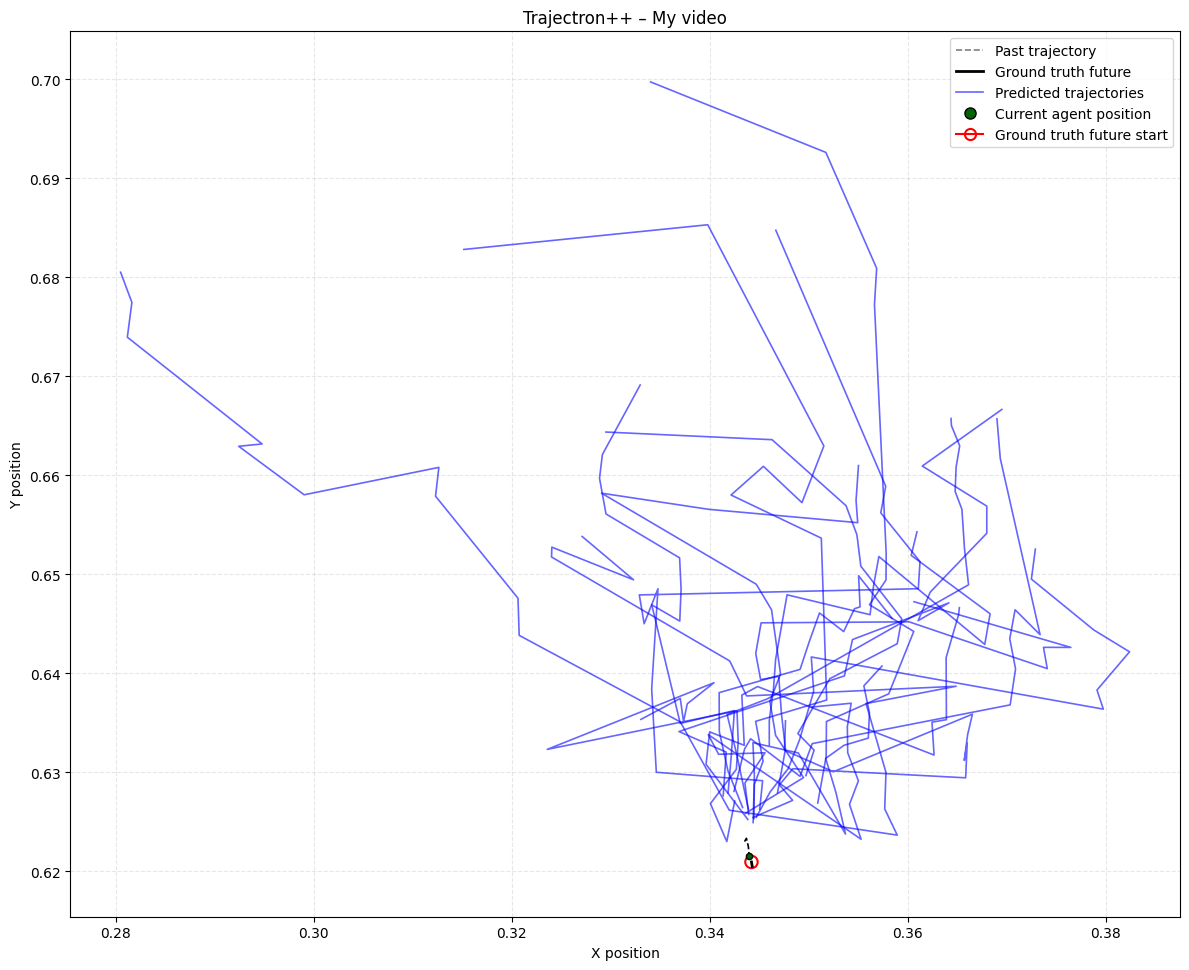

In [24]:
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(12, 12))

# 1) Distribution (GMM ellipses)
visualize_distribution(ax, dists, pi_threshold=0.05)

# 2) Predicted trajectories + past (manual plot for visibility)
pred_dict, hist_dict, fut_dict = prediction_output_to_trajectories(
    {timestep: preds},
    scene.dt,
    hyperparams["maximum_history_length"],
    hyperparams["prediction_horizon"],
    map=None
)

prediction_dict = pred_dict[timestep]
histories_dict = hist_dict[timestep]

cmap = ['k', 'b', 'y', 'g', 'r']
xs, ys = [], []

for node in histories_dict:
    history = histories_dict[node]
    predictions = prediction_dict[node]

    if np.isnan(history[-1]).any():
        continue

    # Past
    ax.plot(history[:, 0], history[:, 1], 'k--', linewidth=1.2)
    xs.append(history[:, 0]); ys.append(history[:, 1])

    # Predicted samples
    for sample_num in range(predictions.shape[1]):
        ax.plot(
            predictions[0, sample_num, :, 0],
            predictions[0, sample_num, :, 1],
            color=cmap[node.type.value],
            linewidth=1.2,
            alpha=0.6
        )
        xs.append(predictions[0, sample_num, :, 0])
        ys.append(predictions[0, sample_num, :, 1])

    # Current position
    ax.scatter(history[-1, 0], history[-1, 1], s=20, color="darkgreen", edgecolors="black", zorder=3)

# 3) Ground truth future (manual)
for node in scene.nodes:
    future = node.get(
        np.arange(timestep + 1, timestep + hyperparams["prediction_horizon"] + 1),
        hyperparams["state"][node.type]
    )
    ax.plot(future[:, 0], future[:, 1], color="black", linewidth=2.0)
    ax.scatter(future[0, 0], future[0, 1], facecolors="none", edgecolors="red", s=80, linewidth=1.5)
    xs.append(future[:, 0]); ys.append(future[:, 1])

# Auto-scale
if xs:
    x = np.concatenate(xs)
    y = np.concatenate(ys)
    mask = ~np.isnan(x) & ~np.isnan(y)
    if mask.any():
        span = max(x[mask].ptp(), y[mask].ptp(), 1e-6)
        pad = 0.05 * span
        ax.set_xlim(x[mask].min() - pad, x[mask].max() + pad)
        ax.set_ylim(y[mask].min() - pad, y[mask].max() + pad)

ax.set_xlabel("X position")
ax.set_ylabel("Y position")
ax.set_title("Trajectron++ – My video")
ax.grid(True, linestyle="--", alpha=0.3)
ax.set_aspect("equal", adjustable="box")

legend_elements = [
    Line2D([0], [0], color="gray", linestyle="--", linewidth=1.2, label="Past trajectory"),
    Line2D([0], [0], color="black", linewidth=2.0, label="Ground truth future"),
    Line2D([0], [0], color="blue", linewidth=1.2, alpha=0.6, label="Predicted trajectories"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="darkgreen",
           markeredgecolor="black", markersize=8, label="Current agent position"),
    Line2D([0], [0], marker="o", color="red", markerfacecolor="none",
           markeredgewidth=1.5, markersize=8, label="Ground truth future start"),
]
ax.legend(handles=legend_elements, loc="upper right", frameon=True)

plt.tight_layout()
plt.show()
